In [1]:
import pandas as pd
df = pd.read_csv('complaints.csv')

/tmp/ipykernel_10729/1484896287.py:2: DtypeWarning: Columns (0: Consumer complaint narrative) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('complaints.csv')


In [2]:
df["Date received"] = pd.to_datetime(df["Date received"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16962062 entries, 0 to 16962061
Data columns (total 16 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   Date received                 datetime64[us]
 1   Product                       str           
 2   Sub-product                   str           
 3   Issue                         str           
 4   Sub-issue                     str           
 5   Consumer complaint narrative  str           
 6   Company public response       str           
 7   Company                       str           
 8   State                         str           
 9   ZIP code                      str           
 10  Tags                          str           
 11  Submitted via                 str           
 12  Date sent to company          str           
 13  Company response to consumer  str           
 14  Timely response?              str           
 15  Complaint ID                  int64      

### Inputs and Label/Outputs
#### Input X :
- Consumer complaint narrative
#### Input Y :
- (Product, Sub-product, Issue, Sub-issue)

For the first modeling experiments, each valid complete taxonomy path will be treated as one class.

Metadata such as company, state, submission method and date will not be used as model input in V1.

Question: Can the complaint narrative alone contain enough information to predict the CFPB taxonomy path?

## Checking NA Values per Columns

In [3]:
print("Consumer complaint narrative NA values " + str(sum(pd.isna(df["Consumer complaint narrative"])==True)))
print("Product NA values " + str(sum(pd.isna(df["Product"])==True)))
print("Sub-product narrative NA values " + str(sum(pd.isna(df["Sub-product"])==True)))
print("Issue " + str(sum(pd.isna(df["Issue"])==True)))
print("Sub-issue " + str(sum(pd.isna(df["Sub-issue"])==True)))


Consumer complaint narrative NA values 13130557
Product NA values 0
Sub-product narrative NA values 235275
Issue 6
Sub-issue 925650


#### Metadata / potentially useful later
- Company
- State
- Submitted via
- Date received

### Investigating Product

In [4]:
mask = pd.isna(df["Consumer complaint narrative"])==False 
df[mask]["Product"].value_counts()

Product
Credit reporting or other personal consumer reports                             1671615
Credit reporting, credit repair services, or other personal consumer reports     807499
Debt collection                                                                  439160
Checking or savings account                                                      185789
Mortgage                                                                         145889
Credit card                                                                      125987
Money transfer, virtual currency, or money service                               120206
Credit card or prepaid card                                                      108683
Student loan                                                                      62409
Vehicle loan or lease                                                             52739
Credit reporting                                                                  31587
Payday loan, title loan,

In [5]:
mask1 = pd.isna(df["Consumer complaint narrative"])==False
mask3 = df["Product"] == "Credit reporting or other personal consumer reports"
mask4 = df["Product"] == "Credit reporting, credit repair services, or other personal consumer reports"
df1 = df[mask1][mask3]["Date received"].sort_values()
df2 = df[mask1][mask4]["Date received"].sort_values()
print("' Earliest Date Credit reporting, credit repair services, or other personal consumer reports'" + str(df2.iloc[0]))
print("' Latest Date Credit reporting, credit repair services, or other personal consumer reports'" + str(df2.iloc[len(df2)-1]))
print("' Earliest Date Credit reporting or other personal consumer reports'" + str(df1.iloc[0]))
print("' Latest Date Credit reporting or other personal consumer reports'" + str(df1.iloc[len(df1)-1]))

/tmp/ipykernel_10729/510115542.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df[mask1][mask3]["Date received"].sort_values()
/tmp/ipykernel_10729/510115542.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df[mask1][mask4]["Date received"].sort_values()


' Earliest Date Credit reporting, credit repair services, or other personal consumer reports'2017-04-24 00:00:00
' Latest Date Credit reporting, credit repair services, or other personal consumer reports'2023-08-25 00:00:00
' Earliest Date Credit reporting or other personal consumer reports'2023-08-25 00:00:00
' Latest Date Credit reporting or other personal consumer reports'2026-07-27 00:00:00


#### Results Shows clean boundary
<p> - Date Credit reporting, credit repair services, or other personal consumer reports : 2017-04-24 -> 2023-08-25 </p>
<p> - Date Credit reporting or other personal consumer reports: 2023-08-25 -> 2026-07-27 </p>

So this is only a Taxonomy label changed . 
Our main problem now if we won't lose all the data .. so mapping the old label to the new label would probably make certain noise

In [6]:
print(df[mask1][mask3]["Sub-product"].unique())
print(df[mask1][mask4]["Sub-product"].unique())

/tmp/ipykernel_10729/929768596.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df[mask1][mask3]["Sub-product"].unique())


<StringArray>
['Credit reporting', 'Other personal consumer report']
Length: 2, dtype: str


/tmp/ipykernel_10729/929768596.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df[mask1][mask4]["Sub-product"].unique())


<StringArray>
[              'Credit reporting', 'Other personal consumer report',
         'Credit repair services',     'Conventional home mortgage']
Length: 4, dtype: str


In [7]:
mask5 = (pd.isna(df["Consumer complaint narrative"])==False) & (df["Product"] == "Credit reporting, credit repair services, or other personal consumer reports") & (df["Sub-product"] == "Credit repair services")
#print(df[mask5])
df_sorted = df[mask5].sort_values(by=['Date received'])
print(df_sorted.iloc[0])
print(df_sorted.iloc[len(df_sorted)-1])

Date received                                                 2017-04-29 00:00:00
Product                         Credit reporting, credit repair services, or o...
Sub-product                                                Credit repair services
Issue                                                               Fraud or scam
Sub-issue                                                                     NaN
Consumer complaint narrative    This company AD Astra Recovery .The amount sho...
Company public response                                                       NaN
Company                                            Ad Astra Recovery Services Inc
State                                                                          TX
ZIP code                                                                    752XX
Tags                                                                          NaN
Submitted via                                                                 Web
Date sent to com

### As mentioned in Taxonomy document
moved “Credit repair services” under the new added product, “Debt or credit management”

In [8]:
mask6 = (pd.isna(df["Consumer complaint narrative"])==False) & (df["Product"] == "Debt or credit management") & (df["Sub-product"] == "Credit repair services")
df_sorted = df[mask6].sort_values(by=['Date received'])
print(df_sorted.iloc[0])


Date received                                                 2023-08-25 00:00:00
Product                                                 Debt or credit management
Sub-product                                                Credit repair services
Issue                                               Problem with customer service
Sub-issue                                                                     NaN
Consumer complaint narrative    XX/XX/23 I logged into my Transunion paid subs...
Company public response         Company has responded to the consumer and the ...
Company                                    TRANSUNION INTERMEDIATE HOLDINGS, INC.
State                                                                          AZ
ZIP code                                                                    853XX
Tags                                                                          NaN
Submitted via                                                                 Web
Date sent to com

In [9]:
print(df[mask5]["Issue"].unique())
print('_____________')
print(df[mask6]["Issue"].unique())

<StringArray>
[                'Confusing or missing disclosures',
                                    'Fraud or scam',
                                   'Excessive fees',
                    'Problem with customer service',
 'Confusing or misleading advertising or marketing',
                         'Unexpected or other fees']
Length: 6, dtype: str
_____________
<StringArray>
[                'Confusing or missing disclosures',
                 'Didn't provide services promised',
 'Confusing or misleading advertising or marketing',
               'Charged upfront or unexpected fees',
                    'Problem with customer service']
Length: 5, dtype: str


As from the documents :
- The issue “Excessive fees” was removed under the sub-product “Credit repair services”. (removed)
- revised “Fraud or scam” issue to “Didn’t provide services promised” under “Credit
repair services”
- "Unexpected or other fees" revised to Charged upfront or unexpected fees

The problem here is that <strong>Excessive fees</strong> was removed .. so what should we do ?

In [10]:
mask = mask5 & (df["Issue"] == "Excessive fees")
df[mask].info()

<class 'pandas.DataFrame'>
Index: 147 entries, 2986343 to 16921290
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date received                 147 non-null    datetime64[us]
 1   Product                       147 non-null    str           
 2   Sub-product                   147 non-null    str           
 3   Issue                         147 non-null    str           
 4   Sub-issue                     0 non-null      str           
 5   Consumer complaint narrative  147 non-null    str           
 6   Company public response       42 non-null     str           
 7   Company                       147 non-null    str           
 8   State                         147 non-null    str           
 9   ZIP code                      147 non-null    str           
 10  Tags                          38 non-null     str           
 11  Submitted via                 147 non

<strong> As number of rows here is 147 , we would exclude them from the training process </strong>

In [11]:
mask = mask5 & (df["Issue"] == "Fraud or scam")
df[mask].info()

<class 'pandas.DataFrame'>
Index: 998 entries, 2985577 to 16949141
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date received                 998 non-null    datetime64[us]
 1   Product                       998 non-null    str           
 2   Sub-product                   998 non-null    str           
 3   Issue                         998 non-null    str           
 4   Sub-issue                     0 non-null      str           
 5   Consumer complaint narrative  998 non-null    str           
 6   Company public response       365 non-null    str           
 7   Company                       998 non-null    str           
 8   State                         988 non-null    str           
 9   ZIP code                      998 non-null    str           
 10  Tags                          184 non-null    str           
 11  Submitted via                 998 non

In [12]:
mask = mask5 & (df["Issue"] == "Unexpected or other fees")
df[mask].info()

<class 'pandas.DataFrame'>
Index: 342 entries, 2993879 to 16933797
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date received                 342 non-null    datetime64[us]
 1   Product                       342 non-null    str           
 2   Sub-product                   342 non-null    str           
 3   Issue                         342 non-null    str           
 4   Sub-issue                     0 non-null      str           
 5   Consumer complaint narrative  342 non-null    str           
 6   Company public response       181 non-null    str           
 7   Company                       342 non-null    str           
 8   State                         341 non-null    str           
 9   ZIP code                      342 non-null    str           
 10  Tags                          56 non-null     str           
 11  Submitted via                 342 non

As we finished checking what happens with Credit repair services now let's check 'Conventional home mortgage'

In [13]:
mask_sub_product = (pd.isna(df["Consumer complaint narrative"])==False) & (df["Product"] == "Credit reporting, credit repair services, or other personal consumer reports") & (df["Sub-product"] == "Conventional home mortgage")
df[mask_sub_product].info()

<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 14581735 to 14581735
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date received                 1 non-null      datetime64[us]
 1   Product                       1 non-null      str           
 2   Sub-product                   1 non-null      str           
 3   Issue                         1 non-null      str           
 4   Sub-issue                     0 non-null      str           
 5   Consumer complaint narrative  1 non-null      str           
 6   Company public response       0 non-null      str           
 7   Company                       1 non-null      str           
 8   State                         1 non-null      str           
 9   ZIP code                      1 non-null      str           
 10  Tags                          0 non-null      str           
 11  Submitted via                 1 n

In [14]:
mask_product = (pd.isna(df["Consumer complaint narrative"])==False)
result = (
    df[mask_product]
    .groupby(['Product','Sub-product','Issue','Sub-issue'],dropna=False) # no Nan dropped as groupby does that normally
    .size()
)
print(result)

Product                  Sub-product                   Issue                                     Sub-issue
Bank account or service  (CD) Certificate of deposit   Account opening, closing, or management   NaN          182
                                                       Deposits and withdrawals                  NaN           76
                                                       Making/receiving payments, sending money  NaN            9
                                                       Problems caused by my funds being low     NaN            2
                                                       Using a debit or ATM card                 NaN            5
                                                                                                             ... 
Virtual currency         Domestic (US) money transfer  Fraud or scam                             NaN            4
                                                       Money was not available when promised   

In [15]:
result_sorted = result.sort_values(ascending=False)
print(result_sorted)

Product                                                                       Sub-product                   Issue                                                                             Sub-issue                                                                  
Credit reporting or other personal consumer reports                           Credit reporting              Incorrect information on your report                                              Information belongs to someone else                                            486737
                                                                                                            Improper use of your report                                                       Reporting company used your report improperly                                  370691
                                                                                                            Problem with a company's investigation into an existing problem           

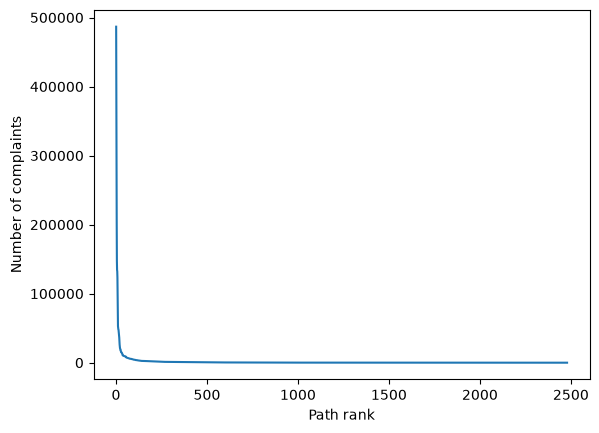

In [16]:
import matplotlib.pyplot as plt
import numpy as np
x = range(1, len(result) + 1)
y = result_sorted.to_numpy()

plt.plot(x, y)

plt.xlabel("Path rank")
plt.ylabel("Number of complaints")
plt.show()

Text(0, 0.5, 'Percentage of complaints')

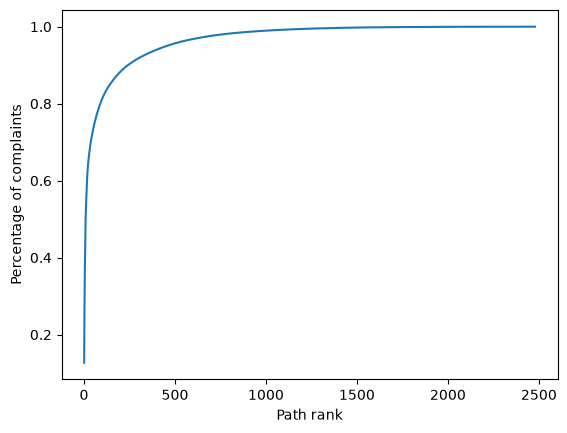

In [17]:
percentage = result_sorted.cumsum()/3831505
x = range(1, len(result) + 1)
y = percentage.to_numpy()

plt.plot(x, y)

plt.xlabel("Path rank")
plt.ylabel("Percentage of complaints")

In [18]:
path_rank_80 = percentage >= 0.80
print("path rank for 80 % coverage " + str(int(path_rank_80.argmax())+1))
path_rank_85 = percentage >= 0.85
print("path rank for 85 % coverage " + str(int(path_rank_85.argmax())+1))
path_rank_90 = percentage >= 0.90
print("path rank for 90 % coverage " + str(int(path_rank_90.argmax())+1))
path_rank_95 = percentage >= 0.95
print("path rank for 95 % coverage " + str(int(path_rank_95.argmax())+1))
path_rank_99 = percentage >= 0.99
print("path rank for 99 % coverage " + str(int(path_rank_99.argmax())+1))

path rank for 80 % coverage 90
path rank for 85 % coverage 143
path rank for 90 % coverage 242
path rank for 95 % coverage 455
path rank for 99 % coverage 1010


In [19]:
Path_rank = [[80,int(path_rank_80.argmax())+1],[85,int(path_rank_85.argmax())+1],[90,int(path_rank_90.argmax())+1],[95,int(path_rank_95.argmax())+1],[99,int(path_rank_99.argmax())+1]]
Move = []
Extra_coverage = []
Extra_paths = []
Extra_paths_per_1_per = []
for i in range(len(Path_rank)-1):
    Move.append(str(Path_rank[i][0]) +  '->' + str(Path_rank[i+1][0]))
for i in range(len(Path_rank)-1):
    Extra_coverage_val = Path_rank[i+1][0] - Path_rank[i][0]
    Extra_coverage.append(Extra_coverage_val)
for i in range(len(Path_rank)-1):
    Extra_paths_val = Path_rank[i+1][1] - Path_rank[i][1]
    Extra_paths.append(Extra_paths_val)
for i in range(len(Extra_paths)):
    Extra_paths_per_val = Extra_paths[i] / Extra_coverage[i] 
    Extra_paths_per_1_per.append(Extra_paths_per_val)
d = {"Move":Move,"Extra_coverage":Extra_coverage,"Extra_paths":Extra_paths,"Extra_paths_per_1_per":Extra_paths_per_1_per}
pd.DataFrame(data=d)

,Move,Extra_coverage,Extra_paths,Extra_paths_per_1_per
0,80->85,5,53,10.60
1,85->90,5,99,19.80
2,90->95,5,213,42.60
3,95->99,4,555,138.75


## Extra paths?
-> Well extra paths is not the right measure .. marginal complexity(Extra paths per ±1% coverage) is .. but we still don't know the real downstream cost in training diffulty
 - Let's first focus on 90 -> 95 .. how are those 213 extra_paths ?
 -> We will calculate the number of complaints per taxonamy path

In [20]:
section_90_95 = result_sorted.iloc[242:455]
section_90_95.describe()

count     213.000000
mean      896.051643
std       201.835755
min       615.000000
25%       731.000000
50%       845.000000
75%      1030.000000
max      1330.000000
dtype: float64

In [21]:
section_80_90 = result_sorted.iloc[90:242]
section_80_90.describe()

count     152.000000
mean     2506.125000
std       933.536779
min      1346.000000
25%      1809.500000
50%      2366.000000
75%      2989.750000
max      5043.000000
dtype: float64

As we can see right here that we will added more taxonomy paths .. but they have weaker statistical support ..

## Investigating 90%
We need here to investigate Product labels

In [22]:
section_90 = result_sorted.iloc[0:242]
section_90.describe()

count       242.000000
mean      14254.078512
std       46867.638155
min        1346.000000
25%        2035.000000
50%        3304.000000
75%        7238.750000
max      486737.000000
dtype: float64

In [23]:
taxonomy_cols = ["Product","Sub-product","Issue","Sub-issue"]
df_paths = pd.MultiIndex.from_frame(df[taxonomy_cols])
mask_90 = df_paths.isin(section_90.index)
mask_narrative = df["Consumer complaint narrative"].notna()
df90_narrative = df[mask_90 & mask_narrative]
print(df90_narrative.shape)
print(df90_narrative[taxonomy_cols].head())

(3449487, 16)
                                             Product       Sub-product  \
0  Credit reporting or other personal consumer re...  Credit reporting   
1  Credit reporting or other personal consumer re...  Credit reporting   
2  Credit reporting or other personal consumer re...  Credit reporting   
3  Credit reporting or other personal consumer re...  Credit reporting   
4  Credit reporting or other personal consumer re...  Credit reporting   

                                  Issue                            Sub-issue  
0  Incorrect information on your report  Information belongs to someone else  
1  Incorrect information on your report       Personal information incorrect  
2  Incorrect information on your report  Information belongs to someone else  
3  Incorrect information on your report  Information belongs to someone else  
4  Incorrect information on your report  Information belongs to someone else  


In [24]:
print(section_90.index.get_level_values(0).unique())


Index(['Credit reporting or other personal consumer reports',
       'Credit reporting, credit repair services, or other personal consumer reports',
       'Money transfer, virtual currency, or money service', 'Debt collection',
       'Checking or savings account', 'Mortgage', 'Credit card',
       'Credit card or prepaid card', 'Student loan', 'Vehicle loan or lease',
       'Credit reporting', 'Bank account or service',
       'Payday loan, title loan, personal loan, or advance loan',
       'Prepaid card', 'Consumer Loan',
       'Payday loan, title loan, or personal loan'],
      dtype='str', name='Product')


In [25]:
result_90 = (
    section_90
    .groupby(level="Product")
    .size()
)
print(result_90)

Product
Bank account or service                                                          4
Checking or savings account                                                     25
Consumer Loan                                                                    3
Credit card                                                                     24
Credit card or prepaid card                                                     18
Credit reporting                                                                 9
Credit reporting or other personal consumer reports                             22
Credit reporting, credit repair services, or other personal consumer reports    19
Debt collection                                                                 55
Money transfer, virtual currency, or money service                              14
Mortgage                                                                        22
Payday loan, title loan, or personal loan                                      

Inspecting the 90 Data

In [26]:
taxonomy_cols = ["Product","Sub-product","Issue","Sub-issue"]
df_paths = pd.MultiIndex.from_frame(df[taxonomy_cols])
mask_90 = df_paths.isin(section_90.index)
mask_narrative = df["Consumer complaint narrative"].notna()
df90_narrative = df[mask_90 & mask_narrative]
print(df90_narrative.shape)
print(df90_narrative[taxonomy_cols].head())

(3449487, 16)
                                             Product       Sub-product  \
0  Credit reporting or other personal consumer re...  Credit reporting   
1  Credit reporting or other personal consumer re...  Credit reporting   
2  Credit reporting or other personal consumer re...  Credit reporting   
3  Credit reporting or other personal consumer re...  Credit reporting   
4  Credit reporting or other personal consumer re...  Credit reporting   

                                  Issue                            Sub-issue  
0  Incorrect information on your report  Information belongs to someone else  
1  Incorrect information on your report       Personal information incorrect  
2  Incorrect information on your report  Information belongs to someone else  
3  Incorrect information on your report  Information belongs to someone else  
4  Incorrect information on your report  Information belongs to someone else  


In [27]:
mask1 = df90_narrative["Product"] == "Credit reporting"
mask2 = df90_narrative["Product"] == "Credit reporting or other personal consumer reports"
mask3 = df90_narrative["Product"] == "Credit reporting, credit repair services, or other personal consumer reports"
df1 = df90_narrative[mask1]["Date received"].sort_values()
df2 = df90_narrative[mask2]["Date received"].sort_values()
df3 = df90_narrative[mask3]["Date received"].sort_values()
print("' Earliest Date Credit reporting'" + str(df1.iloc[0]))
print("' Latest Date Credit reporting'" + str(df1.iloc[len(df1)-1]))
print("' Earliest Date Credit reporting or other personal consumer reports'" + str(df2.iloc[0]))
print("' Latest Date Credit reporting or other personal consumer reports'" + str(df2.iloc[len(df2)-1]))
print("' Earliest Date Credit reporting, credit repair services, or other personal consumer reports'" + str(df3.iloc[0]))
print("' Latest Date Credit reporting, credit repair services, or other personal consumer reports'" + str(df3.iloc[len(df3)-1]))


' Earliest Date Credit reporting'2015-03-19 00:00:00
' Latest Date Credit reporting'2017-04-22 00:00:00
' Earliest Date Credit reporting or other personal consumer reports'2023-08-25 00:00:00
' Latest Date Credit reporting or other personal consumer reports'2026-07-27 00:00:00
' Earliest Date Credit reporting, credit repair services, or other personal consumer reports'2017-04-24 00:00:00
' Latest Date Credit reporting, credit repair services, or other personal consumer reports'2023-08-25 00:00:00


In [28]:
print("Sub-Products :")
print("Credit reporting : \n" + str(df90_narrative[mask1]["Sub-product"].unique().tolist()))
print("Credit reporting or other personal consumer reports : \n" + str(df90_narrative[mask2]["Sub-product"].unique().tolist()))
print("Credit reporting, credit repair services, or other personal consumer reports : \n" + str(df90_narrative[mask3]["Sub-product"].unique().tolist()))


Sub-Products :
Credit reporting : 
[nan]
Credit reporting or other personal consumer reports : 
['Credit reporting', 'Other personal consumer report']
Credit reporting, credit repair services, or other personal consumer reports : 
['Credit reporting', 'Other personal consumer report']


In [29]:
print("Issues :")
print("Credit reporting : \n" + str(df90_narrative[mask1]["Issue"].unique().tolist()))
print("Credit reporting or other personal consumer reports : \n" + str(df90_narrative[mask2]["Issue"].unique().tolist()))
print("Credit reporting, credit repair services, or other personal consumer reports : \n" + str(df90_narrative[mask3]["Issue"].unique().tolist()))


Issues :
Credit reporting : 
['Incorrect information on credit report', "Credit reporting company's investigation", 'Improper use of my credit report']


Credit reporting or other personal consumer reports : 
['Incorrect information on your report', "Problem with a company's investigation into an existing problem", 'Improper use of your report', 'Problem with fraud alerts or security freezes', 'Unable to get your credit report or credit score', 'Credit monitoring or identity theft protection services']
Credit reporting, credit repair services, or other personal consumer reports : 
['Incorrect information on your report', "Problem with a credit reporting company's investigation into an existing problem", 'Improper use of your report', 'Unable to get your credit report or credit score', 'Credit monitoring or identity theft protection services', 'Problem with fraud alerts or security freezes']


In [30]:
print("Sub-issues :")
print("Credit reporting : \n" + str(df90_narrative[mask1]["Sub-issue"].unique().tolist()))
print("Credit reporting or other personal consumer reports : \n" + str(df90_narrative[mask2]["Sub-issue"].unique().tolist()))
print("Credit reporting, credit repair services, or other personal consumer reports : \n" + str(df90_narrative[mask3]["Sub-issue"].unique().tolist()))


Sub-issues :
Credit reporting : 
['Account status', 'Public record', 'Account terms', 'Information is not mine', 'Problem with statement of dispute', 'No notice of investigation status/result', 'Reinserted previously deleted info', 'Personal information', 'Report improperly shared by CRC']
Credit reporting or other personal consumer reports : 
['Information belongs to someone else', 'Personal information incorrect', 'Account information incorrect', 'Their investigation did not fix an error on your report', 'Old information reappears or never goes away', 'Investigation took more than 30 days', 'Reporting company used your report improperly', "Credit inquiries on your report that you don't recognize", 'Account status incorrect', nan, 'Public record information inaccurate', 'Problem with personal statement of dispute', 'Was not notified of investigation status or results', 'Information is missing that should be on the report', 'Other problem getting your report or credit score', 'Problem 

We have 3 datasets : 
 - <strong> 2015-2017 </strong> DATA
 - <strong> 2017-2023 </strong> DATA
 - <strong> 2023-NOW </strong> DATA


In [31]:
mask1= (df90_narrative["Product"] == "Credit reporting") & (df90_narrative["Issue"] == "Incorrect information on credit report")
mask2= (df90_narrative["Product"] == "Credit reporting or other personal consumer reports") & (df90_narrative["Issue"] == "Incorrect information on your report")
print("Old Taxonomy" + str(df90_narrative[mask1]["Sub-issue"].unique().tolist()))
print("Current Taxonomy" + str(df90_narrative[mask2]["Sub-issue"].unique().tolist()))


Old Taxonomy['Account status', 'Public record', 'Account terms', 'Information is not mine', 'Reinserted previously deleted info', 'Personal information']
Current Taxonomy['Information belongs to someone else', 'Personal information incorrect', 'Account information incorrect', 'Old information reappears or never goes away', 'Account status incorrect', 'Public record information inaccurate', 'Information is missing that should be on the report']


In [44]:
mask= (df90_narrative["Product"] == "Credit reporting") & (df90_narrative["Issue"] == "Incorrect information on credit report") & (df90_narrative["Sub-issue"] == "Account terms")
df90_narrative[mask]["Consumer complaint narrative"].head()

13546960                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

These Examples are enough to show that <strong>Account terms</strong> should not be blindly mapped to <strong>Account information incorrect</strong>
For Credit reporting in 2015–2017:
 - Sub-product = NaN
 - the hierarchy is basically:
 - Product → Issue → Sub-issue
 - newer taxonomies use:
 - Product → Sub-product → Issue → Sub-issue
 
It's possible for some branches .. but is it worth it ?
So for V1 , <strong> 2015-2017 </strong> is not that attractive to begin with

So now we continue with : 
 - <strong> 2017-2023 </strong> DATA  : Credit reporting, credit repair services, or other personal consumer reports
 - <strong> 2023-NOW </strong> DATA : Credit reporting or other personal consumer reports
**In the next steps we will**
1. Check the **Sub-products** .. probably map each old column to new column
2. Check the **Issues**
3. Check the **Sub-issues**

In [45]:
mask1 = df90_narrative["Product"] == "Credit reporting"
mask2 = df90_narrative["Product"] == "Credit reporting or other personal consumer reports"
mask3 = df90_narrative["Product"] == "Credit reporting, credit repair services, or other personal consumer reports"
print("Sub-products :")
print("Credit reporting, credit repair services, or other personal consumer reports : \n" + str(df90_narrative[mask3]["Sub-product"].unique().tolist()))
print("Credit reporting or other personal consumer reports : \n" + str(df90_narrative[mask2]["Sub-product"].unique().tolist()))


Sub-products :
Credit reporting, credit repair services, or other personal consumer reports : 
['Credit reporting', 'Other personal consumer report']
Credit reporting or other personal consumer reports : 
['Credit reporting', 'Other personal consumer report']


**Sub-products** are the same name .. so we continue with investigating Issues and Sub-issues

In [46]:
#Starting with Credit Reporting
mask2 = (df90_narrative["Product"] == "Credit reporting or other personal consumer reports") & (df90_narrative["Sub-product"] == "Credit reporting")
mask3 = (df90_narrative["Product"] == "Credit reporting, credit repair services, or other personal consumer reports") & (df90_narrative["Sub-product"] == "Credit reporting")
print("Issues :")
print("Credit reporting, credit repair services, or other personal consumer reports : \n" + str(df90_narrative[mask3]["Issue"].unique().tolist()))
print("Credit reporting or other personal consumer reports : \n" + str(df90_narrative[mask2]["Issue"].unique().tolist()))

Issues :
Credit reporting, credit repair services, or other personal consumer reports : 
['Incorrect information on your report', "Problem with a credit reporting company's investigation into an existing problem", 'Improper use of your report', 'Unable to get your credit report or credit score', 'Credit monitoring or identity theft protection services', 'Problem with fraud alerts or security freezes']
Credit reporting or other personal consumer reports : 
['Incorrect information on your report', "Problem with a company's investigation into an existing problem", 'Improper use of your report', 'Problem with fraud alerts or security freezes', 'Unable to get your credit report or credit score', 'Credit monitoring or identity theft protection services']


In [47]:
old_issues = df90_narrative[mask3]["Issue"].unique().tolist()
new_issues = df90_narrative[mask2]["Issue"].unique().tolist()

rows = []

# exact matches
for issue in old_issues:
    if issue in new_issues:
        rows.append({
            "old": issue,
            "new": issue,
            "mapping_type": "exact"
        })

# renamed issue
rows.append({
    "old": "Problem with a credit reporting company's investigation into an existing problem",
    "new": "Problem with a company's investigation into an existing problem",
    "mapping_type": "rename"
})

df_credit_reporting = pd.DataFrame(rows)

df_credit_reporting

,old,new,mapping_type
0,Incorrect information on your report,Incorrect information on your report,exact
1,Improper use of your report,Improper use of your report,exact
2,Unable to get your credit report or credit score,Unable to get your credit report or credit score,exact
3,Credit monitoring or identity theft protection services,Credit monitoring or identity theft protection services,exact
4,Problem with fraud alerts or security freezes,Problem with fraud alerts or security freezes,exact
5,Problem with a credit reporting company's investigation into an existing problem,Problem with a company's investigation into an existing problem,rename


In [48]:
old_product = "Credit reporting, credit repair services, or other personal consumer reports"
new_product = "Credit reporting or other personal consumer reports"
sub_product = "Credit reporting"

subissue_exact = []
old_only_values = []
new_only_values = []

for _, row in df_credit_reporting.iterrows():

    old_issue = row["old"]
    new_issue = row["new"]

    mask_old = (
        (df90_narrative["Product"] == old_product)
        & (df90_narrative["Sub-product"] == sub_product)
        & (df90_narrative["Issue"] == old_issue)
    )

    mask_new = (
        (df90_narrative["Product"] == new_product)
        & (df90_narrative["Sub-product"] == sub_product)
        & (df90_narrative["Issue"] == new_issue)
    )

    old_subissues = set(
        df90_narrative[mask_old]["Sub-issue"]
        .dropna()
        .unique()
    )

    new_subissues = set(
        df90_narrative[mask_new]["Sub-issue"]
        .dropna()
        .unique()
    )

    subissue_exact.append(old_subissues == new_subissues)
    old_only_values.append(old_subissues - new_subissues)
    new_only_values.append(new_subissues - old_subissues)

df_credit_reporting["subissue_exact"] = subissue_exact
df_credit_reporting["old_only_subissues"] = old_only_values
df_credit_reporting["new_only_subissues"] = new_only_values

df_credit_reporting

,old,new,mapping_type,subissue_exact,old_only_subissues,new_only_subissues
0,Incorrect information on your report,Incorrect information on your report,exact,True,{},{}
1,Improper use of your report,Improper use of your report,exact,False,{},{Report provided to employer without your written authorization}
2,Unable to get your credit report or credit score,Unable to get your credit report or credit score,exact,True,{},{}
3,Credit monitoring or identity theft protection services,Credit monitoring or identity theft protection services,exact,False,{},{Problem canceling credit monitoring or identify theft protection service}
4,Problem with fraud alerts or security freezes,Problem with fraud alerts or security freezes,exact,True,{},{}
5,Problem with a credit reporting company's investigation into an existing problem,Problem with a company's investigation into an existing problem,rename,True,{},{}


In [49]:
#Starting with other personal consumer reports
mask2 = (df90_narrative["Product"] == "Credit reporting or other personal consumer reports") & (df90_narrative["Sub-product"] == "Other personal consumer report")
mask3 = (df90_narrative["Product"] == "Credit reporting, credit repair services, or other personal consumer reports") & (df90_narrative["Sub-product"] == "Other personal consumer report")
print("Issues :")
print("Credit reporting, credit repair services, or other personal consumer reports : \n" + str(df90_narrative[mask3]["Issue"].unique().tolist()))
print("Credit reporting or other personal consumer reports : \n" + str(df90_narrative[mask2]["Issue"].unique().tolist()))

Issues :
Credit reporting, credit repair services, or other personal consumer reports : 
['Improper use of your report']
Credit reporting or other personal consumer reports : 
['Incorrect information on your report', 'Improper use of your report']


***Improper use of your report*** exists in both taxonomy versions and has the same Sub-issue, so this historical path can be mapped directly.

***Incorrect information on your report*** appears only in the current taxonomy within our selected 90% scope. It is therefore kept as a current-only path; no historical mapping is required.

In [50]:
#other personal consumer reports
mask2 = (df90_narrative["Product"] == "Credit reporting or other personal consumer reports") & (df90_narrative["Sub-product"] == "Other personal consumer report") & (df90_narrative["Issue"] == 'Improper use of your report')
mask3 = (df90_narrative["Product"] == "Credit reporting, credit repair services, or other personal consumer reports") & (df90_narrative["Sub-product"] == "Other personal consumer report") & (df90_narrative["Issue"] == 'Improper use of your report')
print("Sub-Issues :")
print("Credit reporting, credit repair services, or other personal consumer reports : \n" + str(df90_narrative[mask3]["Sub-issue"].unique().tolist()))
print("Credit reporting or other personal consumer reports : \n" + str(df90_narrative[mask2]["Sub-issue"].unique().tolist()))

Sub-Issues :
Credit reporting, credit repair services, or other personal consumer reports : 
['Reporting company used your report improperly']
Credit reporting or other personal consumer reports : 
['Reporting company used your report improperly']


# Taxonomy Investigation - V1 Decision

The CFPB taxonomy changes over time. Historical labels cannot always be treated as equivalent to current labels.

### Evidence

- Narrative-present complaints contain **2,479 historical taxonomy paths**.
- The top **242 paths cover approximately 90%** of narrative-present complaints.
- Historical taxonomy versions introduce renamed, added, removed, and restructured labels.
- The 2015–2017 `Credit reporting` branch has no Sub-product and contains ambiguous mappings such as `Account terms`.
- The 2017–2023 credit-reporting taxonomy is substantially more compatible with the current taxonomy, and several mappings were verified directly.

### V1 Decisions

- Use only complaints with a published consumer narrative.
- Use the complaint narrative as the only model input.
- Predict the complete taxonomy path as one class initially.
- Use the approximately **90% coverage path set** as the provisional modeling scope.
- Exclude the 2015–2017 `Credit reporting` branch from V1.
- Apply only historical mappings that we have evidence are safe.
- Do **not** attempt to perfectly normalize every historical CFPB taxonomy change now.

### Known Limitation

Taxonomy normalization is incomplete.

If later error analysis shows that historical taxonomy drift materially hurts model performance, this decision will be revisited.

But for now we will see if we can just continue working with **2023-08-25 onward data**

In [51]:
mask = df["Date received"] >= "2023-08-25"
df_current = df[mask]
df_current.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2025-01-13,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,"Subject : Dispute of XXXX XXXX XXXXXXXX and XXXX XXXX XXXX Account Under FCRA To Whom It May Concern, I am writing to formally dispute the collection account reported on my Experian credit report by XXXX XXXX XXXX and XXXX XXXX XXXX. According to the Nationwide Multistate Licensing System ( NMLS ), this company is not licensed to collect debts in the state of ARIZONA. As such, this accounts reporting is inaccurate and should be permanently removed from my credit report. Under the Fair Credit Reporting Act ( FCRA ), specifically 15 USC 1681e ( b ), Experian is required to follow reasonable procedures to ensure maximum possible accuracy in consumer reports. Reporting a collection account from an entity not authorized to operate in ARIZONA constitutes a violation of this standard. Furthermore, under 15 USC 1681i ( a ) ( 1 ), I am entitled to dispute inaccurate information, and Experian is obligated to investigate and correct or delete unverifiable data. Actions Requested Proof of Licensing : Provide verifiable proof that XXXX XXXX XXXXXXXX, and XXXX XXXX XXXX is licensed to collect debts in ARIZONA. Remove the Inaccurate Entry : If such proof can not be provided, permanently delete this collection account from my credit report. Provide Written Confirmation : Send me written confirmation of the accounts removal and an updated copy of my credit report reflecting the correction. Enclosed are the following documents for your reference : A copy of my credit report highlighting the disputed XXXX XXXX XXXX XXXX XXXX XXXX accounts. Documentation from the Nationwide Multistate Licensing System showing that XXXX XXXX XXXX, AND XXXX XXXX XXXX XXXX is not licensed to collect in ARIZONA. I request that you complete your investigation and provide a response within the 30-day timeframe required under the FCRA. Should you fail to address this matter appropriately, I will escalate my concerns by filing complaints with the Consumer Financial Protection Bureau ( CFPB ), the Federal Trade Commission ( FTC ), and the California Attorney Generals office. Thank you for your prompt attention to this matter. Sincerely, XXXX XXXX",Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,AZ,85340,NaN,Web,2025-01-13,Closed with explanation,Yes,11501339
1,2025-01-13,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Personal information incorrect,"I am currently reviewing my Experian Credit report and there are addresses reporting on my credit report that are not mine. Below is a list of the addresses that I would like to have permanently deleted : XXXX. XXXX XXXX XXXX XXXX XXXX XXXX XXXX, AZ XXXX XXXX. XXXX XXXX XXXX XXXX XXXX XXXX XXXX, TX XXXX",Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,AZ,85340,NaN,Web,2025-01-13,Closed with explanation,Yes,11501252
2,2025-01-13,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,"Subject : Dispute of Debt and Refusal to Pay To Whom It May Concern, I am writing in response to your attempt to collect a debt allegedly owed by me. Pursuant to my rights under the Fair Credit Reporting Act ( FCRA ) and the Fair Debt Collection Practices Act ( FDCPA ), specifically 15 U.S.C. 1692c ( c ), I am formally notifying you that I refuse to pay this debt and dispute its validity. Under 15 U.S.C. 1692c ( c ), once a consumer notifies a debt collector in writi

In [53]:
#Check number of rows
df_current.info()

<class 'pandas.DataFrame'>
Index: 12949193 entries, 0 to 13532260
Data columns (total 16 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   Date received                 datetime64[us]
 1   Product                       str           
 2   Sub-product                   str           
 3   Issue                         str           
 4   Sub-issue                     str           
 5   Consumer complaint narrative  str           
 6   Company public response       str           
 7   Company                       str           
 8   State                         str           
 9   ZIP code                      str           
 10  Tags                          str           
 11  Submitted via                 str           
 12  Date sent to company          str           
 13  Company response to consumer  str           
 14  Timely response?              str           
 15  Complaint ID                  int64         
d

In [57]:
df_current_sorted = df_current.sort_values(by="Date received")
print(df_current_sorted.iloc[0])
print(df_current_sorted.iloc[len(df_current)-1])

Date received                                                                                               2023-08-25 00:00:00
Product                                                                     Credit reporting or other personal consumer reports
Sub-product                                                                                                    Credit reporting
Issue                                                                                      Incorrect information on your report
Sub-issue                                                                                   Information belongs to someone else
Consumer complaint narrative                                                                                                NaN
Company public response         Company has responded to the consumer and the CFPB and chooses not to provide a public response
Company                                                                                  TRANSUNION INTE

### What is known :
 - 12949193 entries
 - Earliest date : 2023-08-25 00:00:00
 - Latest date : 2026-08-07 00:00:00
### Next Steps : 
 - Check missing values
 - Check Duplicates

In [82]:
print(df_current.isnull().sum())
df_current["Complaint ID"] = df_current["Complaint ID"].astype(int)

Date received                          0
Product                                0
Sub-product                            5
Issue                                  6
Sub-issue                         210027
Consumer complaint narrative    10635748
Company public response          5635645
Company                                0
State                              19966
ZIP code                            1809
Tags                            12583994
Submitted via                          0
Date sent to company                   0
Company response to consumer          17
Timely response?                       0
Complaint ID                           0
dtype: int64


In [80]:
df_current.duplicated(subset=["Complaint ID"]).sum().tolist()


0

In [86]:
# Creating narrative-present subset
df_non_na = df_current.dropna(subset=["Consumer complaint narrative"])
print(df_non_na.info())

<class 'pandas.DataFrame'>
Index: 2313445 entries, 0 to 13451851
Data columns (total 16 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   Date received                 datetime64[us]
 1   Product                       str           
 2   Sub-product                   str           
 3   Issue                         str           
 4   Sub-issue                     str           
 5   Consumer complaint narrative  str           
 6   Company public response       str           
 7   Company                       str           
 8   State                         str           
 9   ZIP code                      str           
 10  Tags                          str           
 11  Submitted via                 str           
 12  Date sent to company          str           
 13  Company response to consumer  str           
 14  Timely response?              str           
 15  Complaint ID                  int64         
dt

In [87]:
print(df_non_na.isnull().sum())

Date received                         0
Product                               0
Sub-product                           0
Issue                                 0
Sub-issue                        117957
Consumer complaint narrative          0
Company public response         1053091
Company                               0
State                              8191
ZIP code                            255
Tags                            2154003
Submitted via                         0
Date sent to company                  0
Company response to consumer          7
Timely response?                      0
Complaint ID                          0
dtype: int64


In [91]:
result_current = (
    df_non_na
    .groupby(['Product','Sub-product','Issue','Sub-issue'],dropna=False) # no Nan dropped as groupby does that normally
    .size()
)
print(result.sort_values(ascending=False))

Product                                                                       Sub-product                   Issue                                                                             Sub-issue                                                                  
Credit reporting or other personal consumer reports                           Credit reporting              Incorrect information on your report                                              Information belongs to someone else                                            486737
                                                                                                            Improper use of your report                                                       Reporting company used your report improperly                                  370691
                                                                                                            Problem with a company's investigation into an existing problem           